In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [111]:
# 1. датасет Medical Insurance с Kaggle
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Возмем в качестве целевой переменной charges (стоимость страховки)

In [112]:
median_charges = df['charges'].median()
df['target'] = np.where(df['charges'] > median_charges, 1, 0)
df.head()

,age,sex,bmi,children,smoker,region,charges,target
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,0


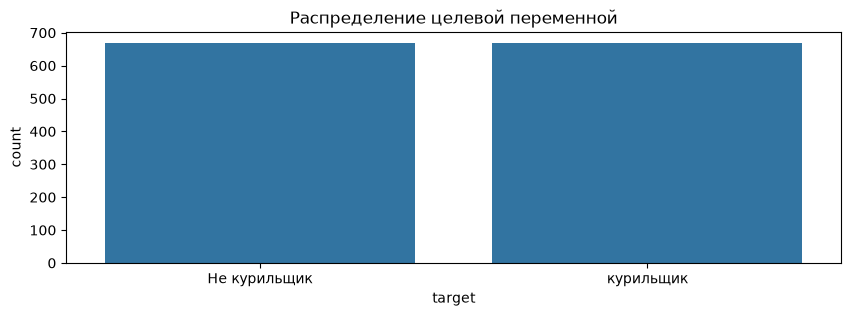

In [113]:
fig, ax = plt.subplots(1,1, figsize = (10,3))
sns.barplot(df['target'].value_counts())
ax.set_title(f'Распределение целевой переменной')
ax.xaxis.set_ticks(range(2))
ax.set_xticklabels(["Не курильщик", "курильщик"])
plt.show()

Распределение естественно равномерное

### Посмотрим от чего зависит целевая переменная

In [114]:
# Преобразуем все в числовой формат с помощью функции get_dummies

df = pd.get_dummies(df, columns = ['sex', 'smoker'], drop_first=True)
df = pd.get_dummies(df, columns = ['region'], drop_first=False)

df.head()

,age,bmi,children,charges,target,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,False,True,False,False,False,True
1,18,33.770,1,1725.55230,0,True,False,False,False,True,False
2,28,33.000,3,4449.46200,0,True,False,False,False,True,False
3,33,22.705,0,21984.47061,1,True,False,False,True,False,False
4,32,28.880,0,3866.85520,0,True,False,False,True,False,False


In [115]:
# Матрица корреляций
corr = df.corr()

# Корреляция с целевой переменной
corr['target'].sort_values(ascending=False)

target              1.000000
charges             0.689856
age                 0.512617
smoker_yes          0.507463
bmi                 0.089896
region_northeast    0.055829
children            0.019227
sex_male           -0.002990
region_southeast   -0.006718
region_northwest   -0.019171
region_southwest   -0.029628
Name: target, dtype: float64

Оставим в качестве предикторов возраст и количество детей

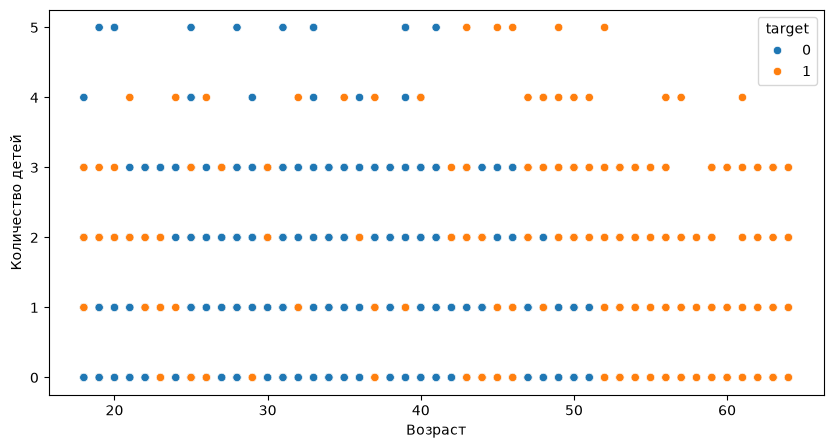

In [116]:
fig, ax = plt.subplots(1,1, figsize = (10, 5))
sns.scatterplot(x = "age", y = "children", data = df, hue = "target", ax = ax)
ax.set_xlabel("Возраст")
ax.set_ylabel("Количество детей")
plt.show()

### Обучим модель KNN

In [117]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train, n_neighbors=3):
    model = KNeighborsClassifier(n_neighbors)
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test, proba = False):
    if proba:
        return model.predict_proba(X_test)[:, 1]
    else:
        return model.predict(X_test)

def visualize_prediction(y_true, y_pred, model):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Accuracy: ', accuracy_score(y_true, y_pred)),
    print('Precision: ', precision_score(y_true, y_pred))
    print('Recall: ', recall_score(y_true, y_pred))
    print('F1: ', f1_score(y_true, y_pred))
    print('ROC-AUC: ', roc_auc_score(y_true, y_pred))

### KNN без масштабирования

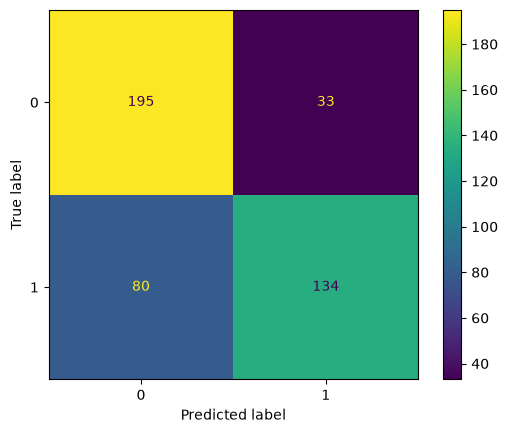

Среднее значение Y:  0.4841628959276018
Accuracy:  0.744343891402715
Precision:  0.8023952095808383
Recall:  0.6261682242990654
F1:  0.7034120734908137
ROC-AUC:  0.7407156910969012


In [132]:
target_col = ["target"]
features_col = ["age", "children"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train.values.ravel())
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

Показатели не плохие, так как возраст неплохо корреллирует с целевой переменной в отличии от детей. А именно возраст без масштабирования перетягивает одеяло на себя

### С масштабированием

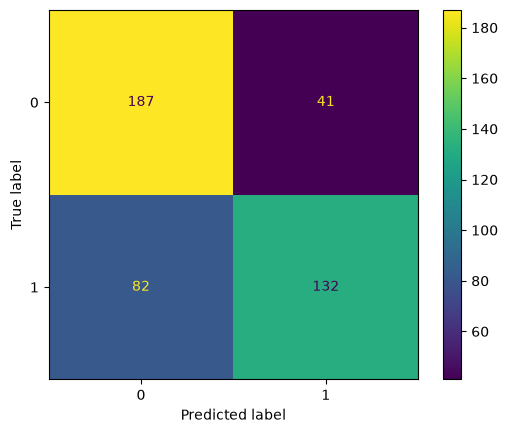

Среднее значение Y:  0.4841628959276018
Accuracy:  0.7217194570135747
Precision:  0.7630057803468208
Recall:  0.616822429906542
F1:  0.6821705426356589
ROC-AUC:  0.7184989342515166


In [133]:
target_col = ["target"]
features_col = ["age", "children"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = train_model(X_train_scaled, y_train.values.ravel())
y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

С масштабированием результат оказался хуже, так влияние детей возрасло, хотя корреляция с целевой переменной маленькая

### Попробуем с курильщиками

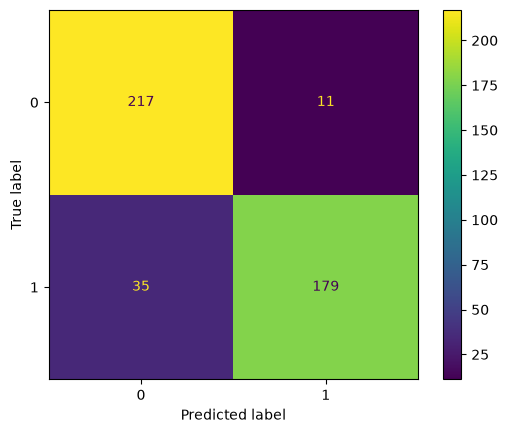

Среднее значение Y:  0.4841628959276018
Accuracy:  0.8959276018099548
Precision:  0.9421052631578948
Recall:  0.8364485981308412
F1:  0.8861386138613861
ROC-AUC:  0.8941014920478767


In [134]:
target_col = ["target"]
features_col = ["age", "smoker_yes"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train.values.ravel())
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

С мими какртина лучше

### Чтобы было проще все сравнивать и делать выводы создадим класс для моделей

In [199]:
class ML_classification:
    def __init__(self, df, features_col, show = False,
                 to_scale=False, random_state=42,
                 test_size=0.33, target_col='target', n_neighbors=3, proba = False):
        self.df = df
        self.features_col = features_col
        self.target_col = target_col
        self.test_size = test_size
        self.random_state = random_state
        self.n_neighbors= n_neighbors
        self.proba = proba

        # сразу готовим данные и обучаем
        self.split_train_test(to_scale=to_scale)
        self.model = self.train_model()
        self.y_pred = self.get_predictions()
        self.set_metrics(self.y_test, self.y_pred)


        if show is True:
            self.visualize_prediction(self.y_test, self.y_pred)
            self.show_metrics()

   
    def split_train_test(self, to_scale=False):
        X = self.df[self.features_col]
        y = self.df[self.target_col]
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )
        if to_scale:
            self.scaler = StandardScaler()
            self.X_train = self.scaler.fit_transform(self.X_train)
            self.X_test = self.scaler.transform(self.X_test)



    def train_model(self):
        model = KNeighborsClassifier(self.n_neighbors)
        model.fit(self.X_train, self.y_train.values.ravel())
        return model

    def get_predictions(self ):
        if self.proba:
            return self.model.predict_proba(self.X_test)[:, 1]
        else:
            return self.model.predict(self.X_test)

    def visualize_prediction(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.model.classes_)
        disp.plot()
        plt.show()

    def set_metrics(self, y_true, y_pred):
        self.mean_Y = np.mean(y_true)
        self.accuracy = accuracy_score(y_true, y_pred)
        self.precision = precision_score(y_true, y_pred)
        self.recall = recall_score(y_true, y_pred)
        self.f1 = f1_score(y_true, y_pred)
        self.roc_auc = roc_auc_score(y_true, y_pred)

    def show_metrics(self):
        print('mean_Y: ', self.mean_Y)
        print('Accuracy: ', self.accuracy),
        print('Precision: ', self.precision)
        print('Recall: ', self.recall)
        print('F1: ', self.f1)
        print('ROC-AUC: ', self.roc_auc)

Создадим 4 класс для сравнения

In [211]:
ml_children=ML_classification(df, target_col = "target" , features_col = ["age", "children"])
ml_children_scale=ML_classification(df, target_col = "target" , features_col = ["age", "children"], to_scale=True)
ml_smoke=ML_classification(df, target_col = "target" , features_col = ["age", "smoker_yes"])
ml_smoke_scale=ML_classification(df, target_col = "target" , features_col = ["age", "smoker_yes"], to_scale=True)

models = {
    'children': ml_children,
    'children_scale': ml_children_scale,
    'smoke': ml_smoke,
    'smoke_scale': ml_smoke_scale,

}


In [206]:
def compare_models(models_dict, figsize=(14, 8)):
    """
    Строит общий график сравнения метрик для нескольких моделей ML_classification.
    
    Parameters:
    -----------
    models_dict : dict
        Словарь вида {'имя_модели': объект_ML_classification, ...}
    figsize : tuple
        Размер фигуры (ширина, высота)
    """
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    n_models = len(models_dict)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # --- График 1: столбчатая диаграмма метрик ---
    ax1 = axes[0]
    x = np.arange(len(metrics_names))
    width = 0.8 / n_models
    
    for i, (name, model) in enumerate(models_dict.items()):
        values = [model.accuracy, model.precision, model.recall, model.f1, model.roc_auc]
        offset = (i - (n_models - 1) / 2) * width
        bars = ax1.bar(x + offset, values, width, label=name, alpha=0.85)
        for bar, val in zip(bars, values):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=45)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_names)
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel('Score')
    ax1.set_title('Сравнение метрик моделей', fontsize=14)
    ax1.legend(loc='lower right')
    ax1.grid(axis='y', alpha=0.3)
    
    # --- График 2: heatmap метрик ---
    ax2 = axes[1]
    metrics_matrix = np.array([
        [model.accuracy, model.precision, model.recall, model.f1, model.roc_auc]
        for model in models_dict.values()
    ])
    
    sns.heatmap(metrics_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=metrics_names, yticklabels=list(models_dict.keys()),
                ax=ax2, vmin=0, vmax=1, cbar_kws={'label': 'Score'})
    ax2.set_title('Тепловая карта метрик', fontsize=14)
    ax2.set_ylabel('Модель')
    
    plt.tight_layout()
    plt.show()

Сравним их

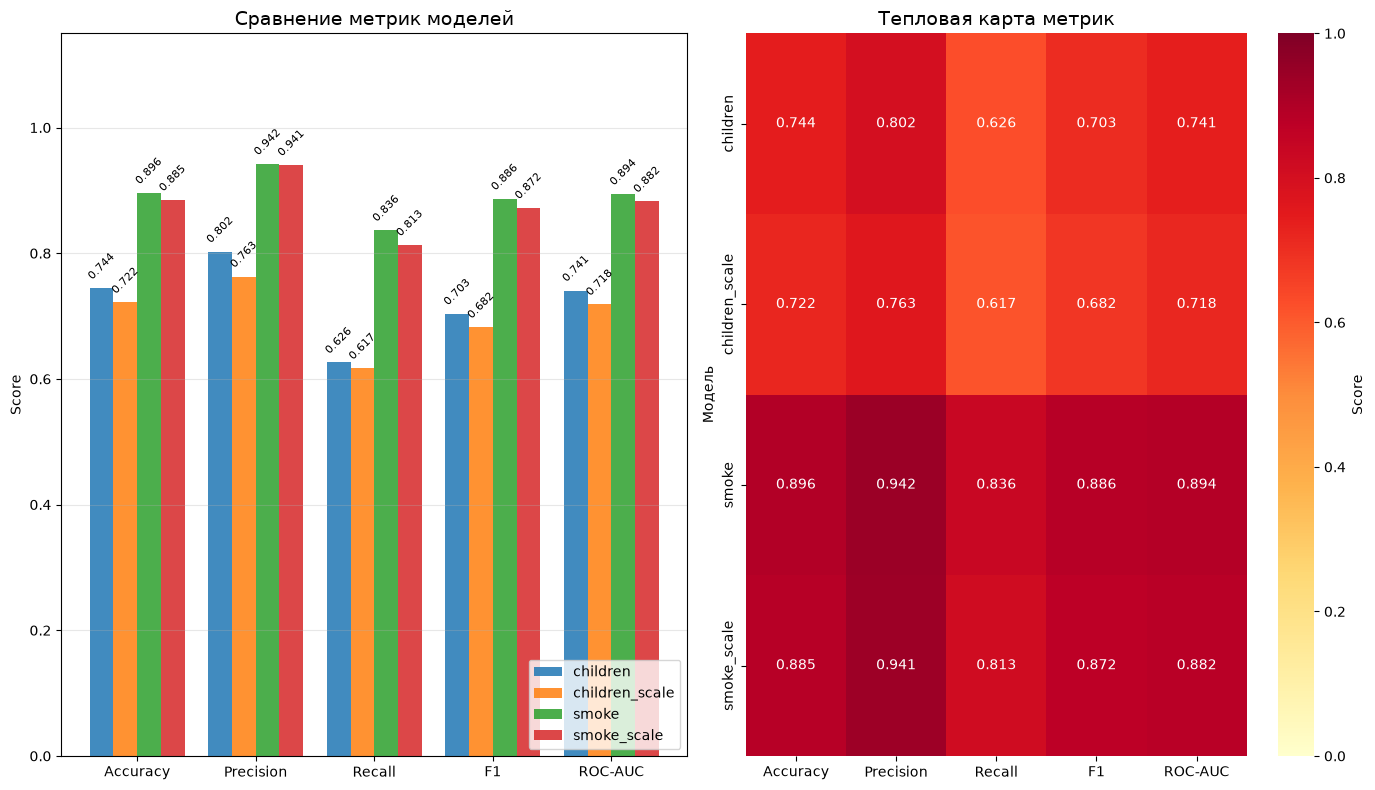

In [212]:
compare_models(models)

Оставим признак курящих и прогоним его на разных вариантах с количеством соседей (по умолчанию было 3) 

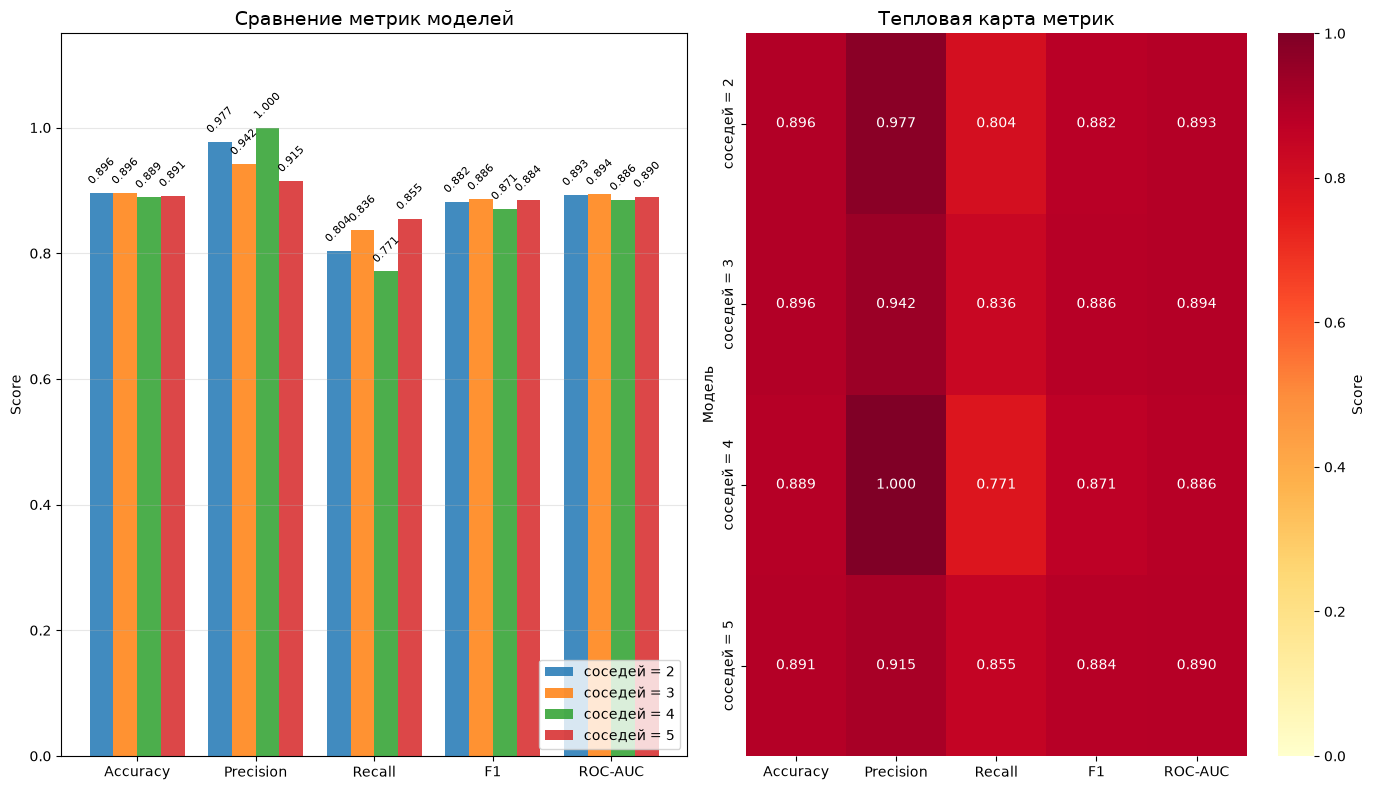

In [231]:
models = {
    f"соседей = {i}": ML_classification(
        df,
        target_col="target",
        features_col=["age", "smoker_yes"],
        n_neighbors=i
    )
    for i in range(2, 6)
}

compare_models(models)

Особой разницы нет, оставим N = 3

### прогоним на разных рандомах

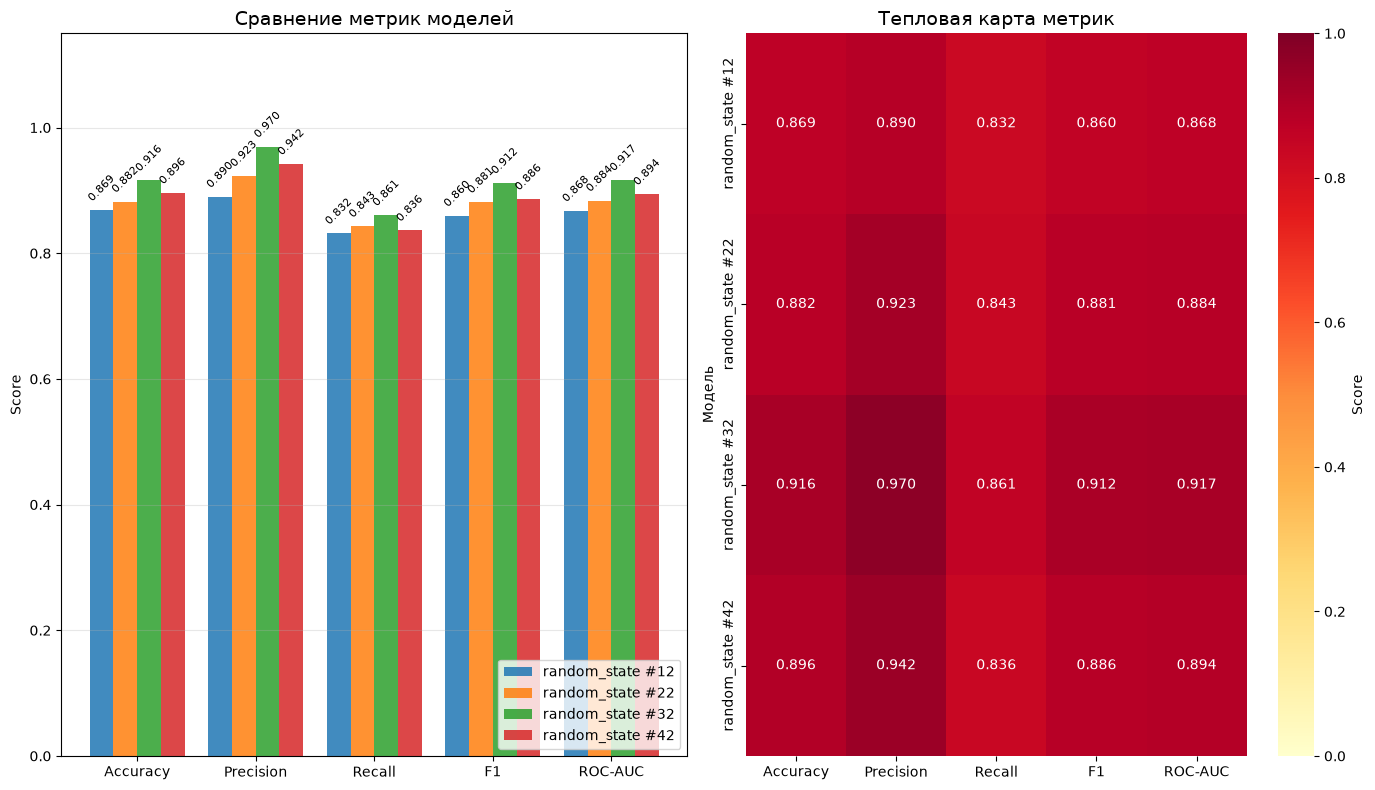

In [232]:
models = {
    f"random_state #{random_state}": ML_classification(
        df,
        target_col="target",
        features_col=["age", "smoker_yes"],
        random_state=random_state
    )
    for random_state in [12, 22, 32, 42]
}

compare_models(models)

Модель показала хорошие результаты. На графике ниже видно классификация ярко выражена

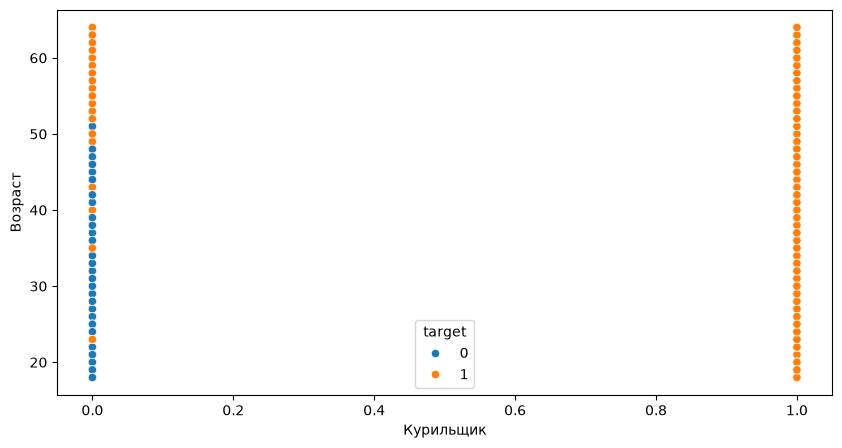

In [236]:
fig, ax = plt.subplots(1,1, figsize = (10, 5))
sns.scatterplot(x = "smoker_yes", y = "age", data = df, hue = "target", ax = ax)
ax.set_xlabel("Курильщик")
ax.set_ylabel("Возраст")
plt.show()